In [1]:
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import glob

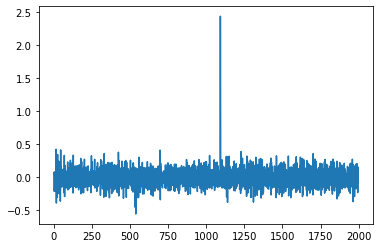

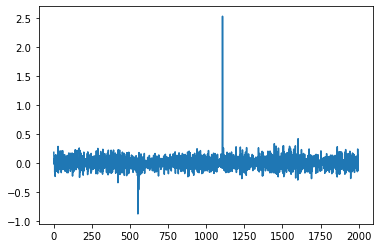

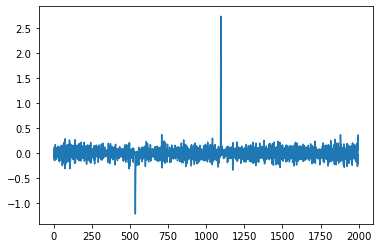

[0.01276846]


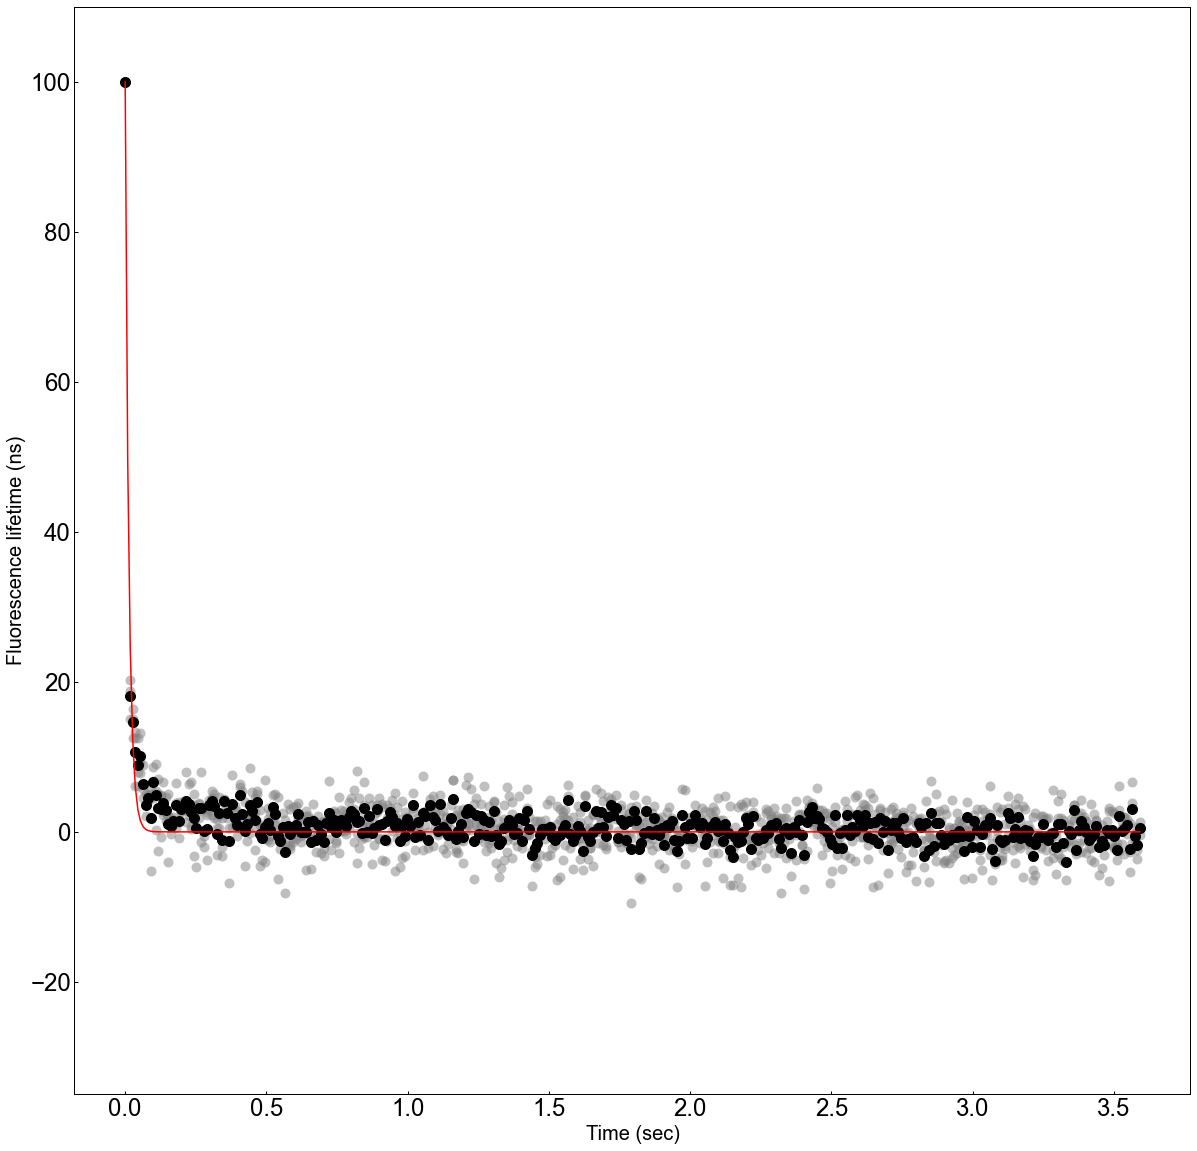

In [2]:
file_paths = glob.glob('./220427_transition_lin22.6_incells_200mW/*.csv')
data_set_lifetime_normed = pd.DataFrame()
total = 0

for path in file_paths:
    
    intensity = np.array(pd.read_csv(path, sep = '\t').iloc[1:, 3], dtype = 'float32')
    lifetime = np.array(pd.read_csv(path, sep = '\t').iloc[1:, 1], dtype = 'float32')[:2000]
    diff = lifetime[:-2] - lifetime[2:]
    plt.plot(diff)
    plt.show()
    index = np.argmax(diff)
    lifetime = lifetime[index:index+400]
    lifetime_normed = (lifetime - np.mean(lifetime[-10:]))*100/(lifetime[0] - np.mean(lifetime[-10:]))
    data_set_lifetime_normed = pd.concat([data_set_lifetime_normed, pd.DataFrame(lifetime_normed)], axis = 1)
    total += lifetime_normed
   
average_normed = total/len(file_paths)

def mono_relaxation(time, t1):
    return np.exp(-time/t1)*100
time = np.ravel([0.009*i for i in range(len(average_normed))])
result = curve_fit(mono_relaxation, time, average_normed)
print(result[0])


fig = plt.figure(figsize = (20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['axes.linewidth'] = 1.0
plt.rcParams["font.size"] = 20
plt.tick_params(axis='both', direction = "in", labelsize = 24)

for num in range(data_set_lifetime_normed.shape[1]):
    plt.plot(np.delete(time, [1]), np.delete(np.array(data_set_lifetime_normed.iloc[:, num]), [1]), color = 'grey', alpha = 0.5, marker = 'o', linewidth = 0, markersize = 10, markeredgewidth = 0)
plt.plot(np.delete(time, [1]), np.delete(average_normed, [1]), color = 'black', marker = 'o', linewidth = 0, markersize = 10)

plt.plot(time, mono_relaxation(time, result[0]), color = 'red')
plt.xlabel('Time (sec)')
plt.ylabel('Fluorescence lifetime (ns)')
plt.ylim(-35, 110)

#pdfのセーブ
pp = PdfPages('./FigS8_FPT_transition_incells.pdf')
pp.savefig(fig)
pp.close()

In [3]:
data_set_lifetime_normed.to_csv("lifetime_normed.csv")
pd.DataFrame(average_normed).to_csv("average_normed.csv")
pd.DataFrame([time, mono_relaxation(time, result[0])]).to_csv("fitting_line.csv")